# Set the Working Directory 
Always set the current working directory to the root of the repo so you can import the helper functions 

In [2]:
import os
# Change to the directory where the script is located to be able to import local modules
os.chdir("..")

In [3]:
from pathlib import Path
cwd = Path.cwd()
print(cwd)

h:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM


# Libraries 

In [4]:
from utils.checkpoints import load_checkpoint
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from utils.checkpoints import load_ckpt_any, latest_checkpoint_path, train_dir, make_train_id
from utils.runs import load_by_params


In [5]:
df_idx = pd.read_parquet(cwd/"results"/"index"/"training.parquet")
df_idx.head(50)

,model,train_id,data_run_id,path,created_at,git_commit,cfg_N,cfg_T,cfg_C,cfg_latent_dim,cfg_num_inducing,cfg_num_inducing_hidden,cfg_treatment_lag,cfg_treatment_model,cfg_init_z,cfg_learn_inducing_locations,cfg_use_titsias,cfg_lr,metrics_json,final_loss
0,seqgplvm,485c53ffdf,4de2f3f4,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T10:38:08Z,None,140.0,4.0,3.0,1.0,50.0,5.0,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,True,False,0.01,"{""final_loss"":0.8532183170318604,""epochs_compl...",0.853218
1,seqgplvm,af3cfc9e14,52af2af0,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T10:38:08Z,None,140.0,4.0,5.0,1.0,50.0,5.0,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,True,False,0.01,"{""final_loss"":1.0533857345581055,""epochs_compl...",1.053386
2,seqgplvm,03e2dfdc81,dadff289,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T10:38:16Z,None,140.0,4.0,3.0,1.0,50.0,5.0,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,True,False,0.01,"{""final_loss"":0.8719741106033325,""epochs_compl...",0.871974
3,seqgplvm,ed193d3c03,a85fc460,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T10:38:08Z,None,140.0,4.0,5.0,1.0,50.0,5.0,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,True,False,0.01,"{""final_loss"":1.0099886655807495,""epochs_compl...",1.009989
4,seqgplvm,c439ef5e65,c27fe204,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T10:38:08Z,None,140.0,20.0,3.0,1.0,50.0,5.0,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,True,False,0.01,"{""final_loss"":12.262765884399414,""epochs_compl...",12.262766
5,seqgplvm,857c24e6f9,2a2b0a99,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T10:38:16Z,None,140.0,20.0,3.0,1.0,50.0,5.0,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,True,False,0.01,"{""final_loss"":11.90421199798584,""epochs_comple...",11.904212
6,seqgplvm,3ff5f36467,3326a253,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T10:38:08Z,None,140.0,20.0,5.0,1.0,50.0,5.0,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,True,False,0.01,"{""final_loss"":13.596718788146973,""epochs_compl...",13.596719
7,seqgplvm,de4d93810f,8c7ecd5b,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T10:38:08Z,None,140.0,20.0,5.0,1.0,50.0,5.0,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,True,False,0.01,"{""final_loss"":12.747291564941406,""epochs_compl...",12.747292
8,seqgplvm,2685fa278c,d9e512c6,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T10:38:08Z,None,140.0,40.0,5.0,1.0,50.0,5.0,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,True,False,0.01,"{""final_loss"":27.477493286132812,""epochs_compl...",27.477493
9,seqgplvm,effab8a799,cbbb93c7,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T10:38:08Z,None,140.0,40.0,3.0,1.0,50.0,5.0,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,True,False,0.01,"{""final_loss"":26.22821044921875,""epochs_comple...",26.228210


In [6]:
df_idx[df_idx.train_id == "485c53ffdf"]

,model,train_id,data_run_id,path,created_at,git_commit,cfg_N,cfg_T,cfg_C,cfg_latent_dim,cfg_num_inducing,cfg_num_inducing_hidden,cfg_treatment_lag,cfg_treatment_model,cfg_init_z,cfg_learn_inducing_locations,cfg_use_titsias,cfg_lr,metrics_json,final_loss
0,seqgplvm,485c53ffdf,4de2f3f4,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T10:38:08Z,None,140.0,4.0,3.0,1.0,50.0,5.0,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,True,False,0.01,"{""final_loss"":0.8532183170318604,""epochs_compl...",0.853218
13,seqgplvm_val,485c53ffdf,4de2f3f4,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T16:58:15Z,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN,"{""final_loss"":7.1501665115356445,""epochs_compl...",7.150167


In [7]:
print(df_idx.shape)

(30, 20)


In [ ]:
44	0d5484a5ce
45	8413cf089b
46	22a497d509
47	80759f94ab
48	821f6a991a
49	1fd206a4f4

In [8]:
model_name = "seqgplvm"
device = "cuda"
tid = 9
train_id = df_idx.train_id.unique()[tid]

train_id = "281b276cad"

train_out = cwd / train_dir(Path(os.environ.get("FINAL_ROOT", "./results")).expanduser(), model_name, train_id)
data_path = json.loads((train_out / "data_ref.json").read_text(encoding="utf-8"))["data_file"]
df = pd.read_parquet(cwd/Path(data_path)/"data.parquet")
df_manifest = json.loads((cwd/Path(data_path)/"manifest.json").read_text(encoding="utf-8"))
splits  = json.loads((cwd/Path(df_manifest["split_file"])).read_text(encoding="utf-8"))
train_split = splits["train_ids"]
val_split   = splits["val_ids"] + splits["test_ids"]

ckpt_path = latest_checkpoint_path(train_out)
payload = load_ckpt_any(ckpt_path, map_location=device)
manifest = json.loads((train_out / "manifest.json").read_text(encoding="utf-8"))
config = json.loads((train_out / "config.json").read_text(encoding="utf-8"))

extra = payload.get("extra")
loss_list     = extra.get("loss_list")
param_hist    = extra.get("param_hist")
actual_params = extra.get("actual_params")

step = config["logging"]["param_logging_freq"]

print(f"loaded model with N: {df_manifest['params']['n']}, T: {df_manifest['params']['T']}, p: {df_manifest['params']['p']}, a: {df_manifest['params']['a']}")

h:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM\utils\checkpoints.py:323: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(tmp_path, map_location=map_lo

loaded model with N: 1250, T: 20, p: 2, a: 1


# Loss 

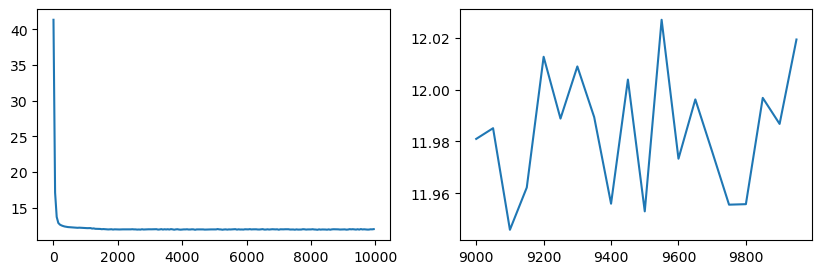

In [9]:
import matplotlib.pyplot as plt

last_n_step = 20
fig,ax = plt.subplots(1,2,figsize = (10,3))
ax[0].plot(np.arange(len(loss_list)) * step , loss_list)
ax[1].plot(range((len(loss_list)- last_n_step) * step , len(loss_list) * step , step) ,loss_list[-last_n_step:])
plt.show()

# Params

In [10]:
specials = {"q_mu": "Z.q_mu", "q_log_sigma": "Z.q_log_sigma"}
specials_val = {"q_mu": "Z_val.q_mu", "q_log_sigma": "Z_val.q_log_sigma"}

if model_name.endswith("_val"):
    specials = specials_val
params = [specials.get(s, s) for s in dict.fromkeys(k.rsplit('.', 1)[-1] for k in param_hist)]

params

['Z.q_mu', 'Z.q_log_sigma', 'raw_constant', 'raw_variance']

In [11]:
from utils.inspectors import plot_param_history

key = 'Z.q_mu'
fig = plot_param_history(param_hist = param_hist, key= key, ls_num=3, x_start= 0, x_step=config["logging"]["param_logging_freq"])
fig

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Z.q_mu_0',
              'type': 'scatter',
              'uid': '70ea27ff-a5f0-42c1-9eba-1415142f06c3',
              'x': {'bdata': ('AAAyAGQAlgDIAPoALAFeAZABwgH0AS' ... 'QcJU4lgCWyJeQlFiZIJnomrCbeJg=='),
                    'dtype': 'i2'},
              'y': {'bdata': ('HT26vzPon7+08Ja/FAWTv9EDkL9GB4' ... 'y/l5qIv97ljL8PI4+/6ZeMv93Kkr8='),
                    'dtype': 'f4'}},
             {'mode': 'lines',
              'name': 'Z.q_mu_1',
              'type': 'scatter',
              'uid': 'de80159e-65ab-4588-9dee-8a277a3267b2',
              'x': {'bdata': ('AAAyAGQAlgDIAPoALAFeAZABwgH0AS' ... 'QcJU4lgCWyJeQlFiZIJnomrCbeJg=='),
                    'dtype': 'i2'},
              'y': {'bdata': ('XS28P/9Tkz9neIY/Lk+CPxClfT8Pz3' ... 'U/JXWvP3zArT//SaU/3xKrPxm7qD8='),
                    'dtype': 'f4'}},
             {'mode': 'lines',
              'name': 'Z.q_mu_2',
              'type': 'scatter',
              '

## Linear Weights 

In [12]:
weights = []
for t in range(config["T"]): 
    weights.append(param_hist[f"gps.{t}.mean_module.weights"][-1])
weights =np.array(weights).squeeze()

KeyError: 'gps.0.mean_module.weights'

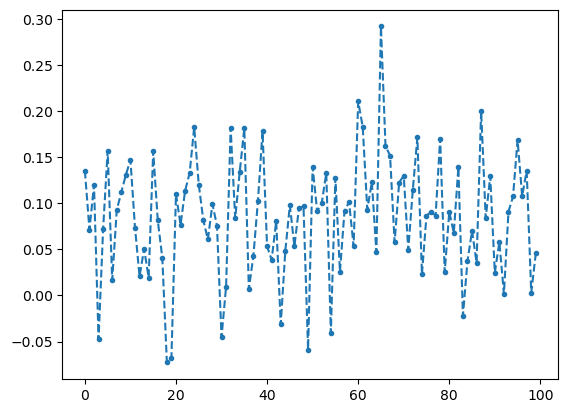

In [112]:
plt.plot(weights[:,3], "--.")

## Latent VS Real Dist

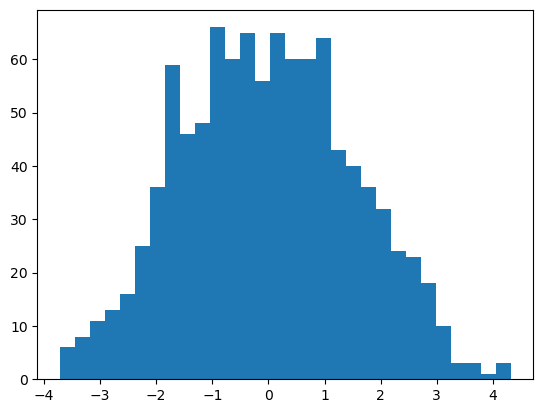

In [12]:
plt.hist(param_hist["Z.q_mu"][-1].squeeze(), bins=30)
plt.show()

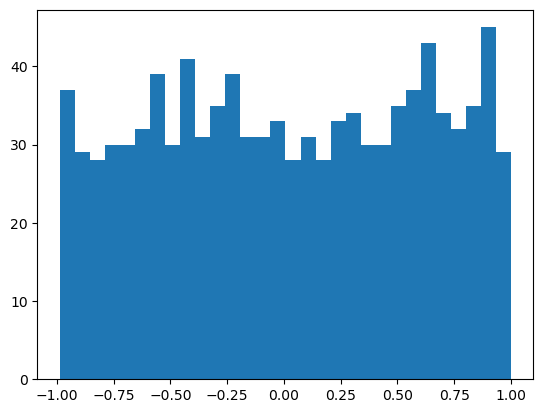

In [13]:
plt.hist(df[df.patient_id.isin(train_split)].drop_duplicates(subset=["patient_id"])["alpha"], bins=30)
plt.show()

## Correlation Between the Estimated Latent and The Real Variable 

In [14]:
id_col = "patient_id"  # or "patient_id"
uniq_ids = df[id_col].unique()
id2row = {pid: i for i, pid in enumerate(uniq_ids)}
train_ids_kept = [pid for pid in train_split if pid in id2row]     # X_train's row order
row_of = {pid: i for i, pid in enumerate(train_ids_kept)}         # pid -> row index in X_train

df_train = df[df[id_col].isin(train_ids_kept)].copy()
df_train["train_row"] = df_train[id_col].map(row_of)
df_train = df_train.sort_values(["train_row", "t"])          # now blocks match X_train rows


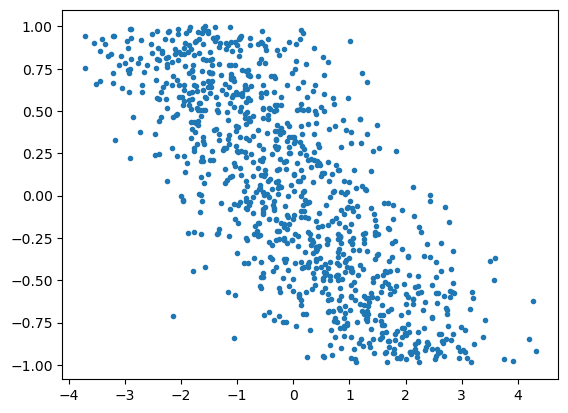

In [15]:
plt.plot(param_hist["Z.q_mu"][-1].squeeze(), df_train.drop_duplicates(subset=["patient_id"]).alpha.to_numpy(), ".")

In [18]:
np.corrcoef(param_hist["Z.q_mu"][-1].squeeze(), df_train.drop_duplicates(subset=["patient_id"]).alpha.to_numpy())

array([[ 1.       , -0.7519051],
       [-0.7519051,  1.       ]])

# Propensity Score 

In [19]:
from trainers.seqgplvm_propensity import propensity_seqgplvm 

propensity_seqgplvm(train_id= train_id, sample_count=100)

h:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM\utils\checkpoints.py:323: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

h:\My Drive\Courses\MasterThesis\Code\NonLinear

Saved log–GPS tensor to: results\propensity\seqgplvm\281b276cad\loggps_281b276cad.pt  shape=(1250, 20, 100)


In [20]:
import torch 
from utils.propensity import propensity_dir
path = propensity_dir(cwd/Path("./results").expanduser(), "seqgplvm", train_id)
payload = torch.load(path/f"loggps_{train_id}.pt", map_location="cpu")
propensity_score = payload["propensity"]

C:\Users\alise\AppData\Local\Temp\ipykernel_55760\4027611034.py:4: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



## PPC

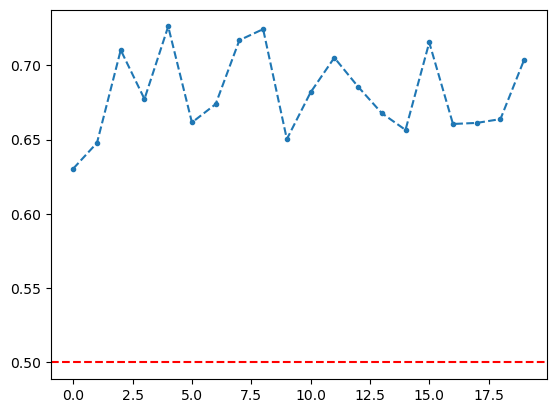

In [21]:
log_gps_z_meaned = payload["log_gps"][payload["index"]["pids_val"]].mean(dim = 2)
log_gps_samples_z_meaned = payload["log_gps_samples_z_meaned"][:,payload["index"]["pids_val"],:]
ppc = (log_gps_samples_z_meaned<log_gps_z_meaned).to(torch.float32).mean(dim=1).mean(dim = 0)
plt.plot(ppc, '.--')
plt.axhline(0.5, color='red', linestyle='--')
plt.show()

In [22]:
P, T, S = propensity_score.shape
arr = propensity_score.detach().cpu().numpy().reshape(P*T, S)

# id columns
patient_id = np.repeat(np.arange(P), T)
t = np.tile(np.arange(1,T+1), P)

# build dataframe
batch_cols = [f"phat_batch_{i+1}" for i in range(S)]
propensity_df = pd.DataFrame(arr, columns=batch_cols)
propensity_df.insert(0, "t", t)
propensity_df.insert(0, "patient_id", patient_id)

df_phat = df.merge(propensity_df,on=["patient_id", "t"], how="inner")
#df_phat[batch_cols] = df_phat[batch_cols].where(
 #   df_phat['D'].eq(1),                  # keep as-is when D == 1
  #  other=1 - df_phat[batch_cols]        # otherwise flip: 1 - value
#)
df_phat["phat_mean"] = df_phat[batch_cols].mean(axis=1)
df_phat["phat_std"] = df_phat[batch_cols].std(axis=1)

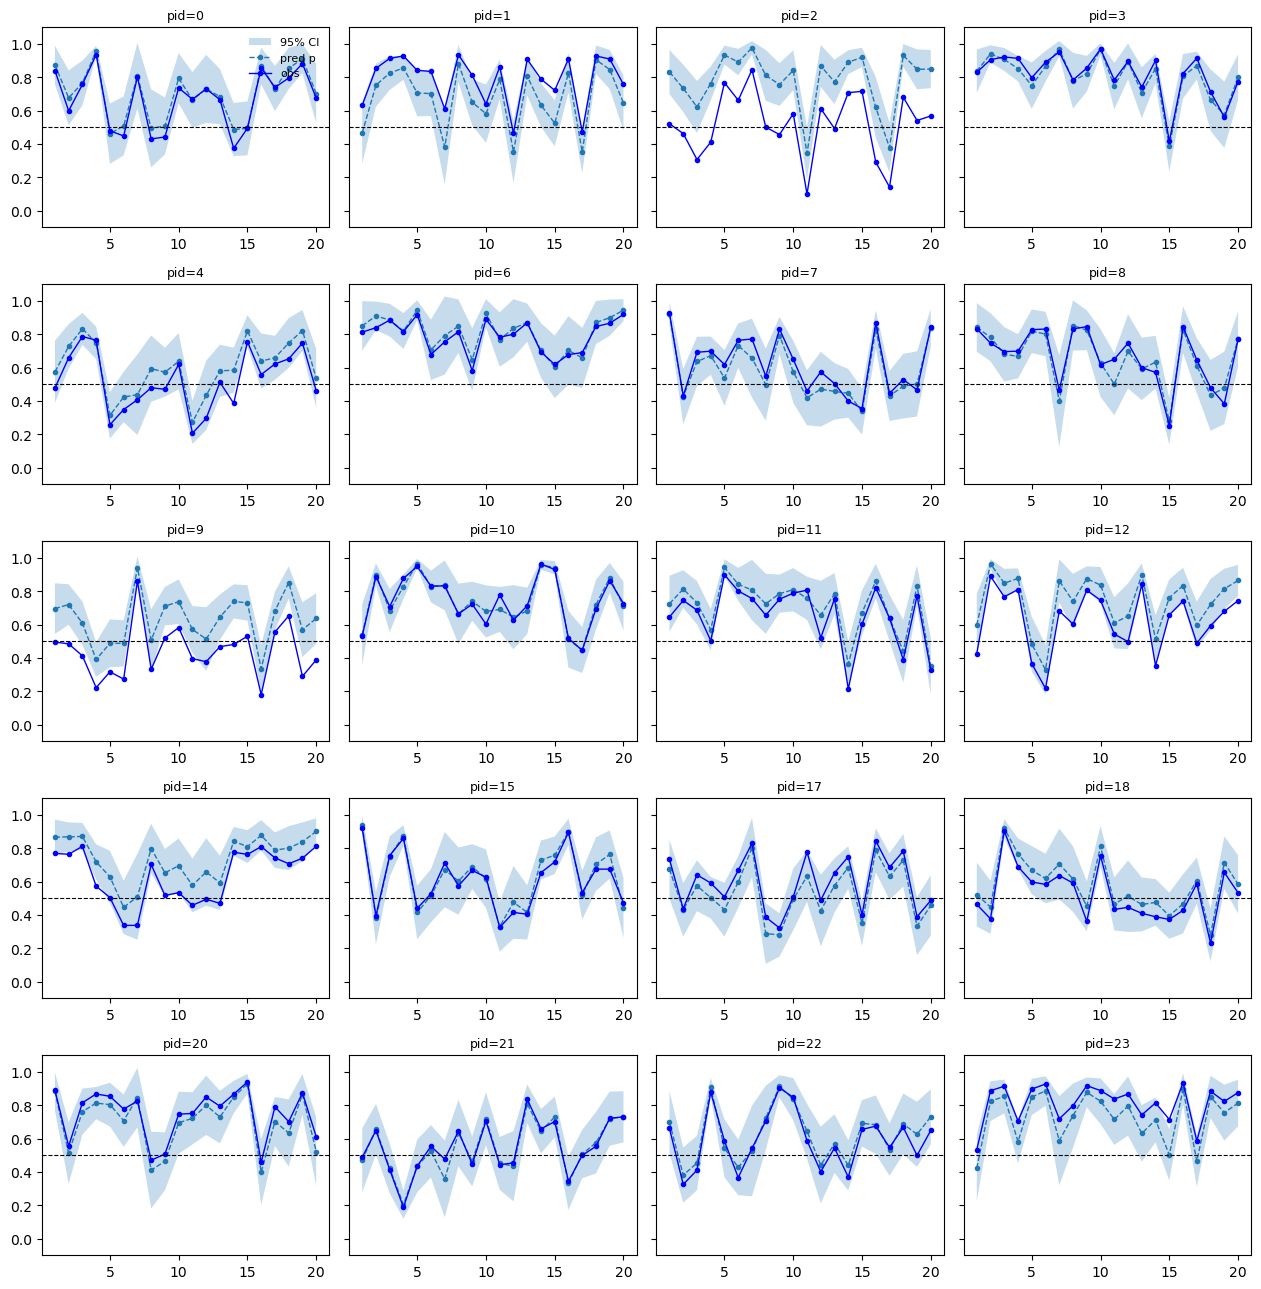

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def plot_patient_grid(pids, df, ncols=4):
    """
    pids: list of patient_ids to show
    df: DataFrame with columns ['patient_id','t','D'] (or at least patient_id & D in order)
    ncols: number of columns in the grid
    """
    n = len(pids)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.6*nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, pid in zip(axes, pids):
        # get predicted traj
        t = df.loc[df.patient_id == pid, "t"].to_numpy()
        pred = df.loc[df.patient_id == pid, "phat_mean"].to_numpy()

        # get observed traj (assumes rows are in time order)
        obs = df.loc[df.patient_id == pid, "p_true"].to_numpy()



        # confidence band
        lo = df.loc[df.patient_id == pid, "phat_mean"] - 1.96 * df.loc[df.patient_id == pid, "phat_std"]
        hi = df.loc[df.patient_id == pid, "phat_mean"] + 1.96 * df.loc[df.patient_id == pid, "phat_std"]
        ax.fill_between(t, lo, hi, alpha=0.25, linewidth=0, label="95% CI")

        ax.plot(t,pred, "--.", lw=1, label="pred p")
        ax.plot(t,obs, ".-", c="blue", lw=1, label="obs")
        #ax.plot((pred >= 0.5).astype(int), ".-", c="orange", lw=1, label="pred 0/1")
        ax.axhline(0.5, color="k", ls="--", lw=0.8)
        ax.set_ylim(-0.1, 1.1)
        ax.set_title(f"pid={pid}", fontsize=9)

    # hide any unused panels
    for ax in axes[n:]:
        ax.axis("off")

    # one legend
    handles, labels = axes[0].get_legend_handles_labels()
    handles, labels = axes.flat[0].get_legend_handles_labels()
    axes.flat[0].legend(handles, labels, loc="upper right", frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

pids_to_show = sorted(payload["index"]["pids_train"])  # pick any
plot_patient_grid(pids_to_show[:20], df_phat, ncols=4)

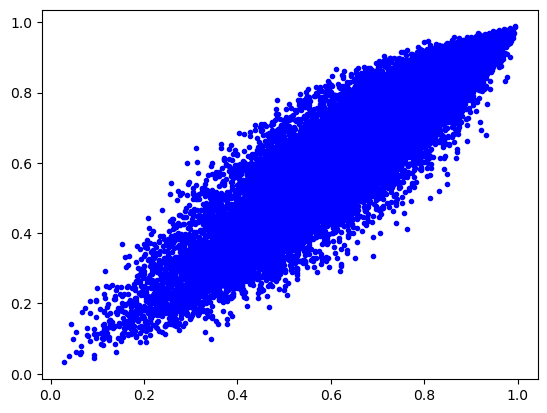

In [24]:
plt.plot(df_phat[df.patient_id.isin(train_split)]["phat_mean"],df_phat[df.patient_id.isin(train_split)]["p_true"],".", c="b", lw=1, label="pred p")
plt.show()

# MSM

## Fix Effect Method 

In [25]:
import statsmodels.api as sm

X_list = []
df_fe = df[df.patient_id.isin(train_split)].copy()
X_list.append(pd.Series(1.0, index=df_fe.index, name="intercept"))
X_list.append(df_fe[["lag1_D"]])
X_list.append(df_fe[df.columns[df.columns.str.startswith("x")].to_list()])
## First without fixed effects
X = pd.concat(X_list, axis=1).astype(float)
y = df_fe["D"].astype(int).values

# GLM Binomial (logit)
model = sm.GLM(y, X, family=sm.families.Binomial())
res = model.fit()

df_fe["phat_no_fe"] = res.predict(X)

fe = pd.get_dummies(df_fe["patient_id"].astype("category"),
                    prefix="u", drop_first=True, dtype=float)
X_list.append(fe)

X = pd.concat(X_list, axis=1).astype(float)
y = df_fe["D"].astype(int).values

# GLM Binomial (logit)
model = sm.GLM(y, X, family=sm.families.Binomial())
res = model.fit()

df_fe["phat_fe"] = res.predict(X)


In [32]:
res.params

intercept    0.654446
lag1_D      -0.004999
x0          -0.519988
x1          -0.553296
u_1         -0.096052
               ...   
u_1245      -2.166842
u_1246      -1.347945
u_1247      -1.884645
u_1248      -0.973845
u_1249      -0.883782
Length: 1003, dtype: float64

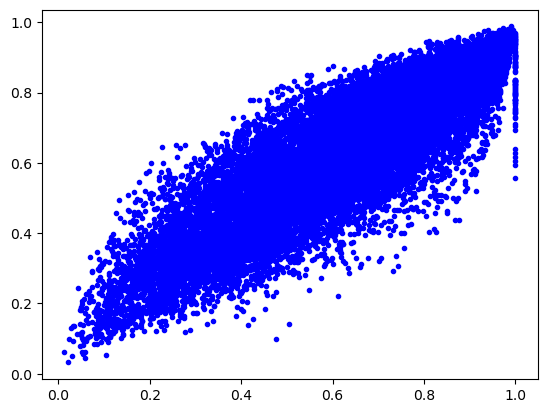

In [26]:
plt.plot(df_fe["phat_fe"], df_fe["p_true"],".", c="b", lw=1, label="pred p")
plt.show()

In [27]:
T = df_manifest['params']['T']
df_phat['lag_sum'] = df_phat[df_phat.columns[df_phat.columns.str.startswith("lag")]].sum(axis=1)
df_msm = df_phat.loc[(df_phat['t'] >= T-3) & (df_phat['t'] <= T), ['patient_id', 't', 'D', "lag_sum"]  + ["Y",'p_true'] + batch_cols ]
df_msm = df_msm[df_msm['patient_id'].isin(train_split)]

df_fe = df_fe.loc[(df_fe['t'] >= T-3) & (df_fe['t'] <= T), ['patient_id', 't', 'D', "phat_fe", "phat_no_fe"]]

weights = (1 / df_msm[batch_cols]).where(df_msm['D'].eq(1), other=1 / (1 - df_msm[batch_cols]))
true_weights = (1 / df_msm["p_true"]).where(df_msm['D'].eq(1), other=1 / (1 - df_msm["p_true"]))
fe_weights = (1 / df_fe["phat_fe"]).where(df_fe['D'].eq(1), other=1 / (1 - df_fe["phat_fe"]))
no_fe_weights = (1 / df_fe["phat_no_fe"]).where(df_fe['D'].eq(1), other=1 / (1 - df_fe["phat_no_fe"]))

# Time-varying cumulative IPTW per row (within patient)
# Useful for MSM trajectory weighting or diagnostics per time step
weights_cum = weights.groupby(df_msm['patient_id'])[batch_cols].cumprod()
weights_cum.columns = [f'ipw_cum_{c}' for c in batch_cols]

weights_cum["ipw_cum_true"] = true_weights.groupby(df_msm['patient_id']).cumprod()
weights_cum["ipw_cum_fe"] = fe_weights.groupby(df_fe['patient_id']).cumprod()
weights_cum["ipw_cum_no_fe"] = no_fe_weights.groupby(df_fe['patient_id']).cumprod()

# Attach to a compact DataFrame (patient_id, t, ipw_cum_*); keep df_msm unchanged
df_msm_ipw = pd.concat([df_msm[['patient_id','t']], weights_cum], axis=1)
df_msm = df_msm.merge(df_msm_ipw, on=['patient_id', 't'], how='left')

In [28]:
df_msm_reg = df_msm[df_msm['t'] == T]
y = df_msm_reg['Y']
X = df_msm_reg[['D', 'lag_sum']]
X = sm.add_constant(X)
tau_f = []
tau_c = []
for i,batch in enumerate(weights_cum.columns):
    model = sm.WLS(y, X, weights=df_msm_reg[batch])
    res = model.fit()
    tau_f.append(res.params.D)
    tau_c.append(res.params.lag_sum)

model = sm.WLS(y, X, weights=df_msm_reg["ipw_cum_true"])
res = model.fit()

tau_f_true = res.params.D
tau_c_true = res.params.lag_sum

# With fixed effects
model = sm.WLS(y, X, weights=df_msm_reg["ipw_cum_fe"])
res = model.fit()
tau_f_fe = res.params.D
tau_c_fe = res.params.lag_sum
# Without fixed effects
model = sm.WLS(y, X, weights=df_msm_reg["ipw_cum_no_fe"])
res = model.fit()
tau_f_no_fe = res.params.D
tau_c_no_fe = res.params.lag_sum

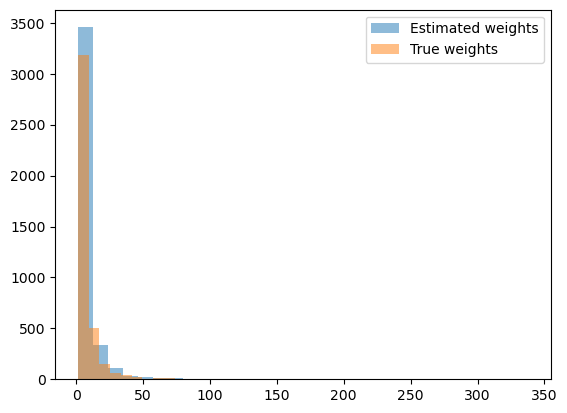

In [29]:
plt.hist(df_msm[weights_cum.columns].mean(axis=1), bins=30, alpha=0.5, label='Estimated weights')
plt.hist(df_msm["ipw_cum_true"], bins=30, alpha=0.5, label='True weights')
plt.legend()
plt.show()

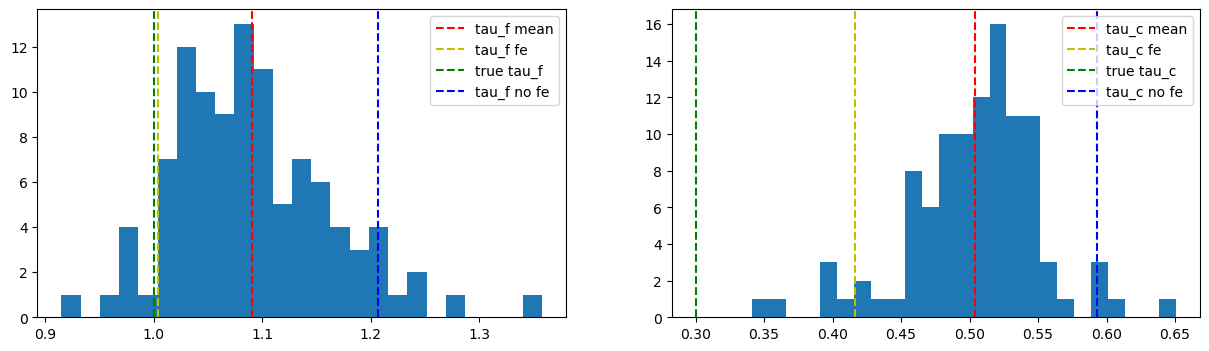

In [30]:
fig,ax = plt.subplots(1,2,figsize = (15,4))
ax[0].hist(np.array(tau_f), bins=25)
ax[0].axvline(x=np.mean(tau_f), color='r', linestyle='--', label='tau_f mean')
ax[0].axvline(x=np.mean(tau_f_fe), color='y', linestyle='--', label='tau_f fe')
ax[0].axvline(x=df_manifest["params"]["tau_F"], color='g', linestyle='--', label='true tau_f')
ax[0].axvline(x=np.mean(tau_f_no_fe), color='b', linestyle='--', label='tau_f no fe')

ax[1].hist(np.array(tau_c), bins=25)
ax[1].axvline(x=np.mean(tau_c), color='r', linestyle='--', label='tau_c mean')
ax[1].axvline(x=np.mean(tau_c_fe), color='y', linestyle='--', label='tau_c fe')
ax[1].axvline(x=df_manifest["params"]["tau_C"], color='g', linestyle='--', label='true tau_c')
ax[1].axvline(x=np.mean(tau_c_no_fe), color='b', linestyle='--', label='tau_c no fe')
ax[0].legend()
ax[1].legend()
plt.show()